In [ ]:
import numpy as np
import pandas as pd
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
from keras import layers
from sklearn.preprocessing import StandardScaler
import numpy as np
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from metrics_tracking import F1Score, plot_metrics


In [35]:
#import the datasets to test
def load_data():
    data = np.load("roads_canids_windows_200hz_3s.npz")
    # Access arrays by their keys
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]
    X_train = X_train[..., :-1] #TEMP FIX REMOVE LATER - FIX PREPROCESSING TO GET RID OF STRING COLUMN
    X_test  = X_test[..., :-1] #TEMP FIX REMOVE LATER
    print(X_train.shape)
    print(y_train.shape)
    print(X_test.shape)
    print(y_test.shape)
    data.close()
    return X_train, y_train, X_test, y_test
X_train, y_train, X_test, y_test = load_data()

(11280, 600, 23)
(11280,)
(13948, 600, 23)
(13948,)


In [36]:
def standardize(X_train, y_train, X_test, y_test):
    # Step 1: Clip outliers (important for ROAD)
    X_train = np.clip(X_train, -1e6, 1e6)
    X_test  = np.clip(X_test,  -1e6, 1e6)
    # Step 2: Standardize features
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat  = X_test.reshape(-1,  X_test.shape[-1])
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)
    X_train = X_train_scaled.reshape(X_train.shape)
    X_test  = X_test_scaled.reshape(X_test.shape)
    return X_train, y_train, X_test, y_test
X_train, y_train, X_test, y_test = standardize(X_train, y_train, X_test, y_test)

In [ ]:
def create_model_road(): #this is the same model we'll always use for all. 
    model = keras.Sequential()
    model.add(layers.Input(shape=(600, 23)))
    model.add(layers.Conv1D(128, 8, activation='relu'))
    model.add(layers.BatchNormalization())   # spreads activation range -added only for int8 optimization later down the road
    model.add(layers.GlobalAveragePooling1D()) #was GlobalMaxPooling1D
    model.add(layers.Dense(1, activation='sigmoid')) #output 1 bc we only have 2 labels: attack or not attack
    return model
model = create_model_road()

In [47]:
#train data 
b_size = 32
callbacks = [
    ModelCheckpoint("saved_models/best_model_road_128cnn.keras", monitor='val_auc', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=8, min_lr=1e-11, verbose=1),
    EarlyStopping(monitor='val_auc', patience=10, verbose=1, restore_best_weights=True)
]
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss = 'binary_crossentropy', 
              metrics = ['accuracy', keras.metrics.AUC(name='auc'), 
              keras.metrics.Precision(name='precision'),
              keras.metrics.Recall(name='recall'),
              F1Score(name="f1")
])
history = model.fit(X_train, y_train, batch_size = b_size, epochs = 50, validation_split=0.1, callbacks = callbacks, verbose = 1)

Epoch 1/50
317/318 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8633 - auc: 0.9357 - f1: 0.4562 - loss: 0.3638 - precision: 0.3268 - recall: 0.8484
Epoch 1: val_auc improved from None to 0.89628, saving model to saved_models/best_model_road_128cnn.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9404 - auc: 0.9582 - f1: 0.6022 - loss: 0.2000 - precision: 0.4847 - recall: 0.7951 - val_accuracy: 0.6977 - val_auc: 0.8963 - val_f1: 0.4888 - val_loss: 0.5734 - val_precision: 0.9209 - val_recall: 0.3327 - learning_rate: 0.0010
Epoch 2/50
317/318 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9825 - auc: 0.9927 - f1: 0.8314 - loss: 0.0502 - precision: 0.8753 - recall: 0.7940
Epoch 2: val_auc improved from 0.89628 to 0.93341, saving model to saved_models/best_model_road_128cnn.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9859 - auc: 0.9969 - f1: 0.8727 - loss: 0.0432 - precision: 0.8958 - recall: 0.8507 - val_accuracy: 0.8732 - val_auc: 0.9334 - val_f1: 0.84

In [51]:
def print_test_metrics(X_test, y_test, model):
    testing_acc = model.evaluate(X_test,y_test, verbose=1)
    print(f"Test loss: {testing_acc[0]}")
    print(f"Test accuracy: {testing_acc[1]}")
    print(f"Test AUC: {testing_acc[2]}")
    print(f"Test Precision: {testing_acc[3]}")
    print(f"Test Recall: {testing_acc[4]}")
    print(f"Test F1: {testing_acc[5]}")
print_test_metrics(X_test, y_test, model)

436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9868 - auc: 0.9599 - f1: 0.6933 - loss: 0.0460 - precision: 0.6933 - recall: 0.6933          
Test loss: 0.045959774404764175
Test accuracy: 0.9868081212043762
Test AUC: 0.9598804712295532
Test Precision: 0.6933333277702332
Test Recall: 0.6933333277702332
Test F1: 0.6933332681655884


In [ ]:
model.save("saved_models/best_ROAD_model128_F1Fixed.keras")

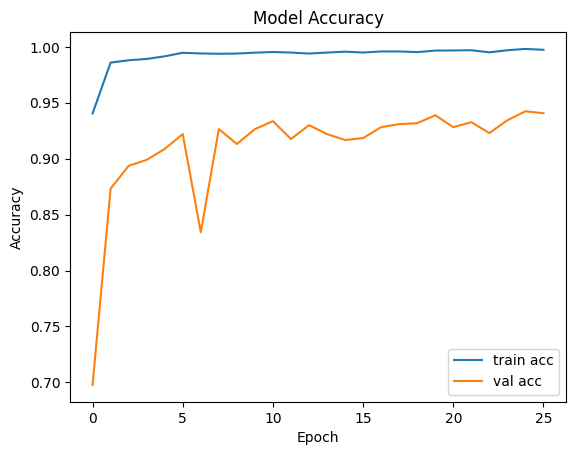

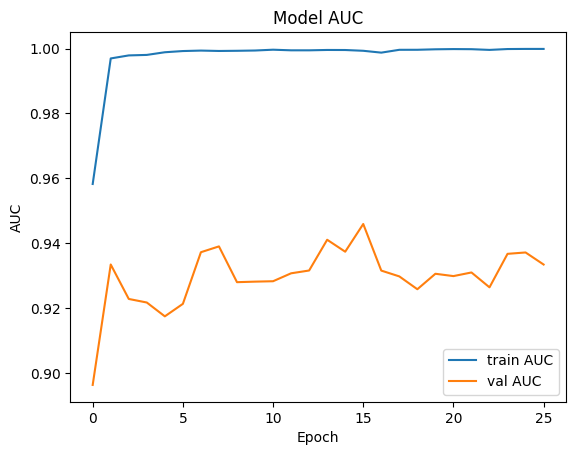

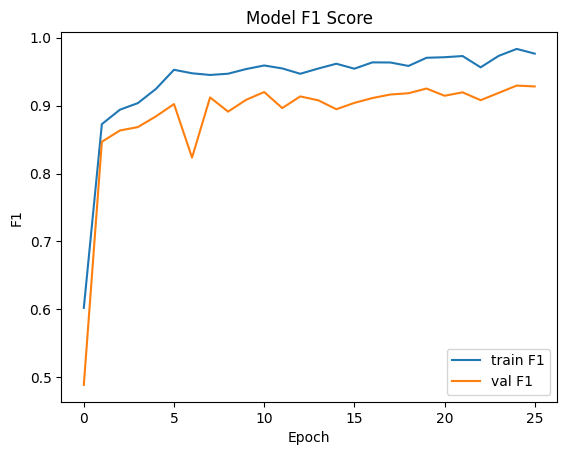

In [52]:
plot_metrics(history)

In [53]:
def print_report_and_score(model, X_test, y_test):
    y_pred_probs = model.predict(X_test).ravel()     # shape: (N,)
    y_pred = (y_pred_probs >= 0.5).astype(int)       # threshold
    print(classification_report(y_test, y_pred, target_names=["Ambient", "Attack"]))
    # --- Correct ROC-AUC for binary classifier ---
    roc_auc = roc_auc_score(y_test, y_pred_probs)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    return y_pred
y_pred = print_report_and_score(model, X_test, y_test)

436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
              precision    recall  f1-score   support

     Ambient       0.99      0.99      0.99     13648
      Attack       0.69      0.69      0.69       300

    accuracy                           0.99     13948
   macro avg       0.84      0.84      0.84     13948
weighted avg       0.99      0.99      0.99     13948

ROC AUC Score: 0.9918


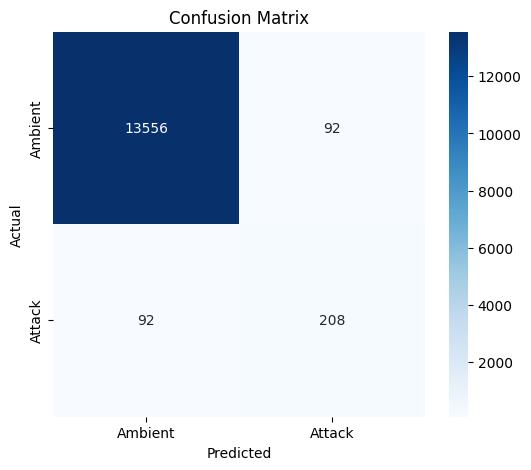

In [54]:
def display_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["Ambient", "Attack"],
        yticklabels=["Ambient", "Attack"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
display_confusion_matrix(y_test, y_pred)